# Gesture Recognition — Training (Game / Snake)

Trains a dedicated neural network for the **snake game** (O10) with 5 classes:
- **idle** — no action
- **sl** — swipe left  → snake turns left
- **sr** — swipe right → snake turns right
- **su** — swipe up    → snake turns up
- **sd** — swipe down  → snake turns down

**Prerequisites:** Run `gesture_recognition_preproc_optionals.ipynb` for all 3 teammates
(we reuse those preprocessed CSVs which contain all 7 labels, then filter here).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys

sys.path.insert(0, str(Path('.').resolve()))

from helper_functions import (
    relu, relu_derivative, softmax,
    cross_entropy_loss, accuracy, f1_score,
    plot_metrics, confusion_matrix_np, plot_confusion_matrix,
    save_training_history, load_training_history,
)
from adam_neural_net import NeuralNetwork

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

PROCESSED_DIR = Path("../data/processed")
EDA_DIR = Path("../visualizations/training")
EDA_DIR.mkdir(parents=True, exist_ok=True)

print("Imports OK")
print(f"Visualizations will be saved to: {EDA_DIR.resolve()}")

Imports OK
Visualizations will be saved to: A:\WS25\ML\final-submission\visualizations\training


## Step 1: Load & Combine Preprocessed Data

In [2]:
files = {
    "arun": PROCESSED_DIR / "arun_preprocessed.csv",
    "aswathy": PROCESSED_DIR / "aswathy_preprocessed.csv",
    "nayana": PROCESSED_DIR / "nayana_preprocessed.csv",
}

dfs = {}
for name, path in files.items():
    if path.exists():
        dfs[name] = pd.read_csv(path)
        print(f"{name}: {dfs[name].shape} | labels: {dict(dfs[name]['label'].value_counts())}")
    else:
        print(f"WARNING: {path} not found")

combined_df = pd.concat(dfs.values(), ignore_index=True)
print(f"\nCombined: {combined_df.shape}")
print(combined_df["label"].value_counts())

arun: (4309, 94) | labels: {'idle': np.int64(3186), 'r_ccw': np.int64(256), 'r_cw': np.int64(233), 'sd': np.int64(199), 'su': np.int64(176), 'sr': np.int64(136), 'sl': np.int64(123)}
aswathy: (3631, 94) | labels: {'idle': np.int64(2857), 'r_ccw': np.int64(191), 'r_cw': np.int64(189), 'su': np.int64(118), 'sr': np.int64(103), 'sl': np.int64(98), 'sd': np.int64(75)}
nayana: (3390, 94) | labels: {'idle': np.int64(2485), 'r_ccw': np.int64(169), 'r_cw': np.int64(164), 'sd': np.int64(158), 'sr': np.int64(157), 'sl': np.int64(145), 'su': np.int64(112)}

Combined: (11330, 94)
label
idle     8528
r_ccw     616
r_cw      586
sd        432
su        406
sr        396
sl        366
Name: count, dtype: int64


## Step 2: Filter to Game Labels

Keep only the 5 classes needed for snake game control:
idle, sl (left), sr (right), su (up), sd (down).

In [3]:
GAME_LABELS = {"idle", "sl", "sr", "su", "sd"}

before = len(combined_df)
combined_df = combined_df[combined_df["label"].isin(GAME_LABELS)].reset_index(drop=True)
print(f"Filtered: {before} -> {len(combined_df)} (dropped r_cw, r_ccw)")
print(combined_df["label"].value_counts())

Filtered: 11330 -> 10128 (dropped r_cw, r_ccw)
label
idle    8528
sd       432
su       406
sr       396
sl       366
Name: count, dtype: int64


## Step 3: Create Sliding Windows

In [4]:
TARGET_FPS = 30
WINDOW_SIZE = 18  # 0.6s at 30 FPS
STRIDE = 5

NON_FEATURES = {"gesture_type", "ground_truth", "label", "person", "source_file", "time"}
feature_cols = [c for c in combined_df.columns if c not in NON_FEATURES]
print(f"Feature columns: {len(feature_cols)}")

def make_windows(df, feature_cols, window, stride):
    X_all, y_all = [], []
    mid = window // 2
    for _, g in df.groupby("source_file"):
        g = g.sort_values("time").reset_index(drop=True)
        feats = g[feature_cols].to_numpy(dtype=np.float32)
        labels = g["label"].to_numpy()
        if len(g) < window:
            continue
        for start in range(0, len(g) - window + 1, stride):
            X_all.append(feats[start:start+window])
            y_all.append(labels[start + mid])
    return np.stack(X_all), np.array(y_all)

X_win, y_win = make_windows(combined_df, feature_cols, WINDOW_SIZE, STRIDE)
print(f"X_win: {X_win.shape}, y_win: {y_win.shape}")
print(f"Labels: {dict(zip(*np.unique(y_win, return_counts=True)))}")

Feature columns: 90
X_win: (1981, 18, 90), y_win: (1981,)
Labels: {np.str_('idle'): np.int64(1664), np.str_('sd'): np.int64(85), np.str_('sl'): np.int64(73), np.str_('sr'): np.int64(81), np.str_('su'): np.int64(78)}


## Step 4: Balance + Label Encode + Flatten + Split + Standardize

In [5]:
# ---- Balance (undersample idle) ----
y = np.array([str(v) for v in y_win])
idle_idx = np.where(y == "idle")[0]
gesture_idx = np.where(y != "idle")[0]

IDLE_RATIO = 2
target_idle = min(len(idle_idx), IDLE_RATIO * len(gesture_idx))
rng = np.random.default_rng(42)
idle_keep = rng.choice(idle_idx, size=target_idle, replace=False)
keep_idx = np.concatenate([gesture_idx, idle_keep])
rng.shuffle(keep_idx)

X_bal = X_win[keep_idx]
y_bal = y[keep_idx]
print(f"Balanced: {X_bal.shape}")
print(f"Distribution: {dict(zip(*np.unique(y_bal, return_counts=True)))}")

# ---- Label encoding ----
unique_labels = sorted(np.unique(y_bal))
label_to_idx = {l: i for i, l in enumerate(unique_labels)}
idx_to_label = {i: l for l, i in label_to_idx.items()}
NUM_CLASSES = len(unique_labels)

print(f"\nLabel mapping ({NUM_CLASSES} classes):")
for l, i in label_to_idx.items():
    print(f"  {l:8s} -> {i}  ({np.sum(y_bal == l)} windows)")

y_int = np.array([label_to_idx[l] for l in y_bal], dtype=np.int32)
y_onehot = np.zeros((len(y_int), NUM_CLASSES), dtype=np.float32)
y_onehot[np.arange(len(y_int)), y_int] = 1.0

# ---- Flatten ----
N, W, F = X_bal.shape
X_flat = X_bal.reshape(N, W * F).astype(np.float64)
input_dim = W * F
print(f"\nFlattened: {X_bal.shape} -> {X_flat.shape}")

# ---- Stratified split ----
def stratified_split(X, y_int, y_oh, train_r=0.70, val_r=0.15, seed=42):
    rng = np.random.default_rng(seed)
    train_idx, val_idx, test_idx = [], [], []
    for cls in np.unique(y_int):
        ci = np.where(y_int == cls)[0]
        rng.shuffle(ci)
        n_train = int(round(len(ci) * train_r))
        n_val = int(round(len(ci) * val_r))
        train_idx.extend(ci[:n_train])
        val_idx.extend(ci[n_train:n_train + n_val])
        test_idx.extend(ci[n_train + n_val:])
    for idx_list in [train_idx, val_idx, test_idx]:
        arr = np.array(idx_list)
        rng.shuffle(arr)
        idx_list[:] = arr.tolist()
    ti, vi, tsi = np.array(train_idx), np.array(val_idx), np.array(test_idx)
    return (X[ti], y_int[ti], y_oh[ti],
            X[vi], y_int[vi], y_oh[vi],
            X[tsi], y_int[tsi], y_oh[tsi])

X_train, y_train_int, y_train_oh, \
X_val,   y_val_int,   y_val_oh, \
X_test,  y_test_int,  y_test_oh = stratified_split(X_flat, y_int, y_onehot)

print(f"Split: Train={X_train.shape[0]}, Val={X_val.shape[0]}, Test={X_test.shape[0]}")

# ---- Standardize ----
train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)
train_std[train_std == 0] = 1.0

X_train = (X_train - train_mean) / train_std
X_val   = (X_val   - train_mean) / train_std
X_test  = (X_test  - train_mean) / train_std
print("Standardized (fit on train).")

Balanced: (951, 18, 90)
Distribution: {np.str_('idle'): np.int64(634), np.str_('sd'): np.int64(85), np.str_('sl'): np.int64(73), np.str_('sr'): np.int64(81), np.str_('su'): np.int64(78)}

Label mapping (5 classes):
  idle     -> 0  (634 windows)
  sd       -> 1  (85 windows)
  sl       -> 2  (73 windows)
  sr       -> 3  (81 windows)
  su       -> 4  (78 windows)

Flattened: (951, 18, 90) -> (951, 1620)
Split: Train=666, Val=143, Test=142
Standardized (fit on train).


## Step 5: Train Neural Network

In [6]:
def accuracy_fn(y_pred_idx, y_true_idx):
    return np.mean(y_pred_idx == y_true_idx)

def f1_macro(y_pred_idx, y_true_idx, num_classes):
    f1s = []
    for c in range(num_classes):
        tp = np.sum((y_pred_idx == c) & (y_true_idx == c))
        fp = np.sum((y_pred_idx == c) & (y_true_idx != c))
        fn = np.sum((y_pred_idx != c) & (y_true_idx == c))
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        f1s.append(f1)
    return np.mean(f1s)

def ce_loss(y_pred, y_true):
    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

def train_model(model, X_train, y_train_oh, y_train_int,
                X_val, y_val_oh, y_val_int,
                epochs=150, batch_size=64,
                optimizer='adam', lr=0.001,
                patience=20, lr_patience=10, lr_factor=0.5, seed=42):
    model.init_optimizer(optimizer=optimizer, lr=lr)
    rng = np.random.default_rng(seed)
    n_train = X_train.shape[0]
    n_batches = max(1, n_train // batch_size)
    nc = y_train_oh.shape[1]

    history = {'train_loss': [], 'val_loss': [],
               'train_acc': [], 'val_acc': [],
               'train_f1': [], 'val_f1': [], 'lr': []}

    best_val_loss = np.inf
    best_weights, best_biases = None, None
    wait, lr_wait, current_lr = 0, 0, lr

    for epoch in range(1, epochs + 1):
        model.training = True
        perm = rng.permutation(n_train)
        X_shuf, y_shuf = X_train[perm], y_train_oh[perm]

        for b in range(n_batches):
            s, e = b * batch_size, min((b+1) * batch_size, n_train)
            y_pred = model.forward(X_shuf[s:e])
            grads_w, grads_b = model.backward(y_shuf[s:e])
            model.update(grads_w, grads_b)

        tr_pred = model.predict(X_train)
        tr_proba = model.predict_proba(X_train)
        tr_loss = ce_loss(tr_proba, y_train_oh)
        tr_acc = accuracy_fn(tr_pred, y_train_int)
        tr_f1 = f1_macro(tr_pred, y_train_int, nc)

        v_pred = model.predict(X_val)
        v_proba = model.predict_proba(X_val)
        v_loss = ce_loss(v_proba, y_val_oh)
        v_acc = accuracy_fn(v_pred, y_val_int)
        v_f1 = f1_macro(v_pred, y_val_int, nc)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(v_acc)
        history['train_f1'].append(tr_f1)
        history['val_f1'].append(v_f1)
        history['lr'].append(current_lr)

        marker = ""
        if v_loss < best_val_loss:
            best_val_loss = v_loss
            best_weights = [w.copy() for w in model.weights]
            best_biases = [b.copy() for b in model.biases]
            wait, lr_wait = 0, 0
            marker = " *"
        else:
            wait += 1
            lr_wait += 1

        if lr_wait >= lr_patience and current_lr > 1e-6:
            current_lr *= lr_factor
            model.lr = current_lr
            lr_wait = 0

        if epoch % 10 == 0 or epoch == 1 or wait == 0:
            print(f"Epoch {epoch:3d} | T: {tr_loss:.4f}/{tr_acc:.3f}/{tr_f1:.3f} | "
                  f"V: {v_loss:.4f}/{v_acc:.3f}/{v_f1:.3f}{marker}")

        if wait >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    if best_weights:
        model.weights = best_weights
        model.biases = best_biases
        print(f"Restored best weights (val_loss={best_val_loss:.4f})")

    return history

print("Training function defined")

Training function defined


In [7]:
model = NeuralNetwork(
    layer_sizes=[input_dim, 128, 64, NUM_CLASSES],
    dropout_rate=0.25,
    l2_lambda=1e-4,
    seed=42
)

print(f"Architecture: {model.layer_sizes}")
print(f"Parameters: {sum(w.size + b.size for w, b in zip(model.weights, model.biases)):,}")
print(f"Classes: {NUM_CLASSES} ({list(label_to_idx.keys())})")

history = train_model(
    model, X_train, y_train_oh, y_train_int,
    X_val, y_val_oh, y_val_int,
    epochs=300, batch_size=64,
    optimizer='adam', lr=0.001,
    patience=40, lr_patience=15, lr_factor=0.5
)

Architecture: [1620, 128, 64, 5]
Parameters: 216,069
Classes: 5 ([np.str_('idle'), np.str_('sd'), np.str_('sl'), np.str_('sr'), np.str_('su')])
Epoch   1 | T: 0.4055/0.866/0.788 | V: 0.6164/0.853/0.781 *
Epoch   2 | T: 0.2304/0.919/0.880 | V: 0.5137/0.846/0.786 *
Epoch   3 | T: 0.1477/0.944/0.919 | V: 0.3920/0.874/0.822 *
Epoch   4 | T: 0.1087/0.962/0.949 | V: 0.3106/0.888/0.842 *
Epoch   5 | T: 0.0887/0.971/0.963 | V: 0.2794/0.902/0.865 *
Epoch   6 | T: 0.0667/0.974/0.966 | V: 0.2468/0.902/0.864 *
Epoch  10 | T: 0.0344/0.991/0.988 | V: 0.2635/0.916/0.883
Epoch  20 | T: 0.0104/0.998/0.998 | V: 0.3142/0.930/0.912
Epoch  30 | T: 0.0038/1.000/1.000 | V: 0.3340/0.923/0.900
Epoch  40 | T: 0.0027/1.000/1.000 | V: 0.3415/0.923/0.900
Early stopping at epoch 46
Restored best weights (val_loss=0.2468)


## Step 6: Learning Curves & Test Evaluation

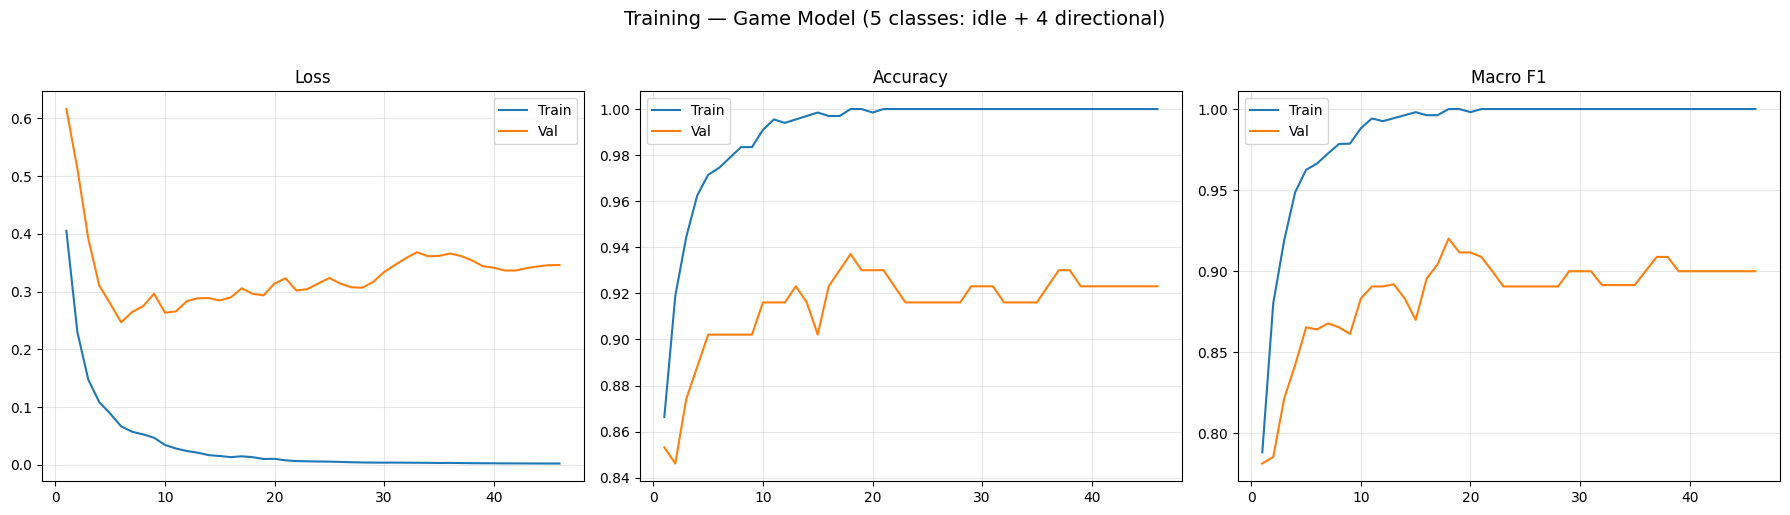

Training history saved -> ..\visualizations\training\history_adam_game.npz  (Adam (Game, 5-class))


In [8]:
# Learning curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ep = np.arange(1, len(history['train_loss']) + 1)

axes[0].plot(ep, history['train_loss'], label='Train')
axes[0].plot(ep, history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(ep, history['train_acc'], label='Train')
axes[1].plot(ep, history['val_acc'], label='Val')
axes[1].set_title('Accuracy'); axes[1].legend()

axes[2].plot(ep, history['train_f1'], label='Train')
axes[2].plot(ep, history['val_f1'], label='Val')
axes[2].set_title('Macro F1'); axes[2].legend()

plt.suptitle('Training — Game Model (5 classes: idle + 4 directional)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(str(EDA_DIR / 'learning_curves_game.png'), dpi=150, bbox_inches='tight')
plt.show()

# Save raw training history
save_training_history(
    history, EDA_DIR / 'history_adam_game.npz',
    model_name='Adam (Game, 5-class)',
    metadata={'architecture': str(model.layer_sizes), 'optimizer': 'adam', 'lr': 0.001}
)

TEST SET RESULTS (Game — 5 classes)
  Loss     : 0.3039
  Accuracy : 0.8732
  Macro F1 : 0.8289

Class            Prec   Recall       F1  Support
------------------------------------------------
idle            0.897    0.916    0.906       95
sd              0.615    0.615    0.615       13
sl              1.000    0.818    0.900       11
sr              0.857    1.000    0.923       12
su              0.889    0.727    0.800       11


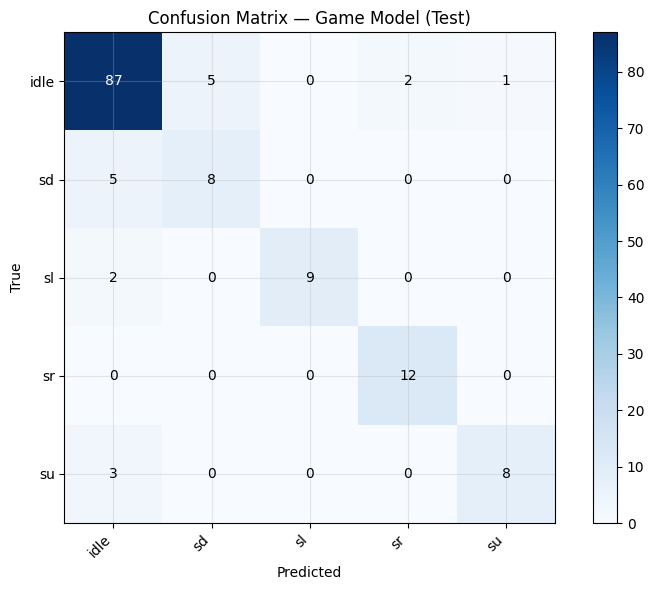

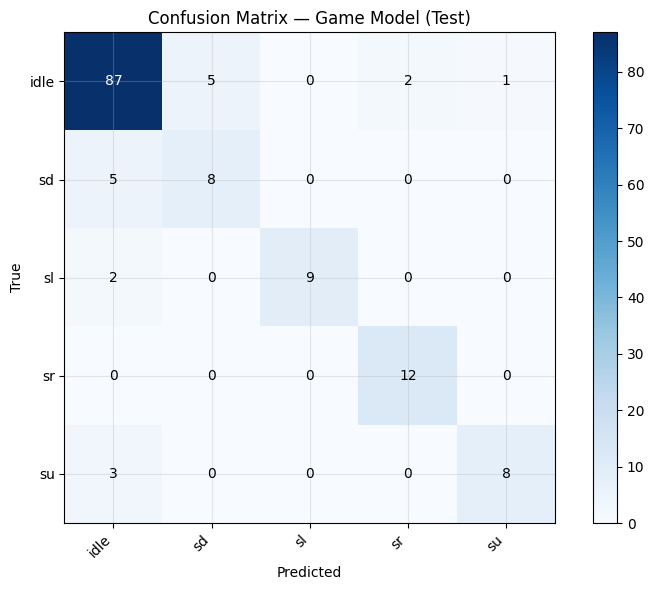

In [9]:
# Test evaluation
y_test_pred = model.predict(X_test)
y_test_proba = model.predict_proba(X_test)

test_loss = ce_loss(y_test_proba, y_test_oh)
test_acc = accuracy_fn(y_test_pred, y_test_int)
test_f1 = f1_macro(y_test_pred, y_test_int, NUM_CLASSES)

print("=" * 50)
print("TEST SET RESULTS (Game — 5 classes)")
print("=" * 50)
print(f"  Loss     : {test_loss:.4f}")
print(f"  Accuracy : {test_acc:.4f}")
print(f"  Macro F1 : {test_f1:.4f}")
print("=" * 50)

# Per-class
print(f"\n{'Class':<12} {'Prec':>8} {'Recall':>8} {'F1':>8} {'Support':>8}")
print("-" * 48)
for c in range(NUM_CLASSES):
    tp = np.sum((y_test_pred == c) & (y_test_int == c))
    fp = np.sum((y_test_pred == c) & (y_test_int != c))
    fn = np.sum((y_test_pred != c) & (y_test_int == c))
    support = np.sum(y_test_int == c)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    print(f"{idx_to_label[c]:<12} {prec:>8.3f} {rec:>8.3f} {f1:>8.3f} {support:>8d}")

# Confusion matrix
cm = confusion_matrix_np(y_test_int, y_test_pred, NUM_CLASSES)
class_names = [idx_to_label[i] for i in range(NUM_CLASSES)]
plot_confusion_matrix(cm, class_names=class_names,
                      title='Confusion Matrix — Game Model (Test)',
                      save_path=EDA_DIR / 'confusion_matrix_game.png')

## Step 7: Save Model Weights (Game)

Saved to `data/processed/game/` with standard filenames used by the multi-model pipeline.

In [10]:
GAME_DIR = PROCESSED_DIR / 'game'
GAME_DIR.mkdir(parents=True, exist_ok=True)

# ---- Model weights ----
weights_path = GAME_DIR / 'model_weights.npz'
np.savez(
    weights_path,
    **{f'W{i}': w for i, w in enumerate(model.weights)},
    **{f'b{i}': b for i, b in enumerate(model.biases)},
    layer_sizes=np.array(model.layer_sizes),
)
print(f"Saved model weights -> {weights_path}")

# ---- Scaler ----
scaler_path = GAME_DIR / 'scaler_params.npz'
np.savez(scaler_path, mean=train_mean, std=train_std)
print(f"Saved scaler -> {scaler_path}")

# ---- Label mapping ----
labels_path = GAME_DIR / 'label_mapping.npz'
np.savez(
    labels_path,
    labels=np.array(list(label_to_idx.keys())),
    indices=np.array(list(label_to_idx.values())),
)
print(f"Saved label mapping -> {labels_path}")
print(f"  Classes: {label_to_idx}")
print("All game model artifacts saved to:", GAME_DIR.resolve())
print(f"\nUsage:  python live_gesture_recognition.py --model game")

Saved model weights -> ..\data\processed\game\model_weights.npz
Saved scaler -> ..\data\processed\game\scaler_params.npz
Saved label mapping -> ..\data\processed\game\label_mapping.npz
  Classes: {np.str_('idle'): 0, np.str_('sd'): 1, np.str_('sl'): 2, np.str_('sr'): 3, np.str_('su'): 4}
All game model artifacts saved to: A:\WS25\ML\final-submission\data\processed\game

Usage:  python live_gesture_recognition.py --model game
